In [1]:
# Cell 1: Imports and load processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load processed data saved in Phase 3
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# .squeeze() converts single-column DataFrame → Series

print("✅ Processed data loaded successfully")
print(f"   X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

✅ Processed data loaded successfully
   X_train: (16512, 13) | y_train: (16512,)
   X_test:  (4128, 13)  | y_test:  (4128,)


In [2]:
# Cell 2: Reusable model evaluation function
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Train a model and return all evaluation metrics.
    Prices are in log scale — we convert back for interpretable metrics.
    """
    # Train
    model.fit(X_train, y_train)

    # Predict on both sets
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Convert log predictions back to original scale
    # We used np.log1p to transform, so np.expm1 reverses it
    y_train_actual = np.expm1(y_train)
    y_test_actual  = np.expm1(y_test)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_pred_orig  = np.expm1(y_test_pred)

    # Calculate metrics on original scale (interpretable in $100k)
    metrics = {
        'Model'     : name,
        'Train MAE' : mean_absolute_error(y_train_actual, y_train_pred_orig),
        'Test MAE'  : mean_absolute_error(y_test_actual,  y_test_pred_orig),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_actual, y_train_pred_orig)),
        'Test RMSE' : np.sqrt(mean_squared_error(y_test_actual,  y_test_pred_orig)),
        'Train R²'  : r2_score(y_train_actual, y_train_pred_orig),
        'Test R²'   : r2_score(y_test_actual,  y_test_pred_orig),
    }

    return metrics, model, y_test_pred_orig, y_test_actual

print("✅ evaluate_model() function defined")
print("\n📌 Why convert back from log scale?")
print("   MAE of 0.15 in log scale has no intuitive meaning.")
print("   MAE of $25,000 in original scale is immediately understandable.")

✅ evaluate_model() function defined

📌 Why convert back from log scale?
   MAE of 0.15 in log scale has no intuitive meaning.
   MAE of $25,000 in original scale is immediately understandable.


In [3]:
# Cell 3: Linear Regression — the baseline model
print("=" * 55)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 55)
print("""
Theory:
  • Assumes a LINEAR relationship between features and price
  • Learns one weight (coefficient) per feature
  • Fast to train, highly interpretable
  • Works well when relationships are actually linear
  
Limitations:
  • Cannot capture non-linear patterns
  • Sensitive to outliers
  • Assumes features are independent (not always true)
""")

lr_model = LinearRegression()
lr_metrics, lr_model, lr_preds, y_actual = evaluate_model(
    "Linear Regression",
    lr_model,
    X_train, X_test, y_train, y_test
)

print(f"  Train R²  : {lr_metrics['Train R²']:.4f}")
print(f"  Test  R²  : {lr_metrics['Test R²']:.4f}")
print(f"  Test  MAE : ${lr_metrics['Test MAE']*100_000:,.0f}")
print(f"  Test  RMSE: ${lr_metrics['Test RMSE']*100_000:,.0f}")

MODEL 1: LINEAR REGRESSION

Theory:
  • Assumes a LINEAR relationship between features and price
  • Learns one weight (coefficient) per feature
  • Fast to train, highly interpretable
  • Works well when relationships are actually linear

Limitations:
  • Cannot capture non-linear patterns
  • Sensitive to outliers
  • Assumes features are independent (not always true)

  Train R²  : 0.6165
  Test  R²  : 0.5990
  Test  MAE : $46,876
  Test  RMSE: $72,492


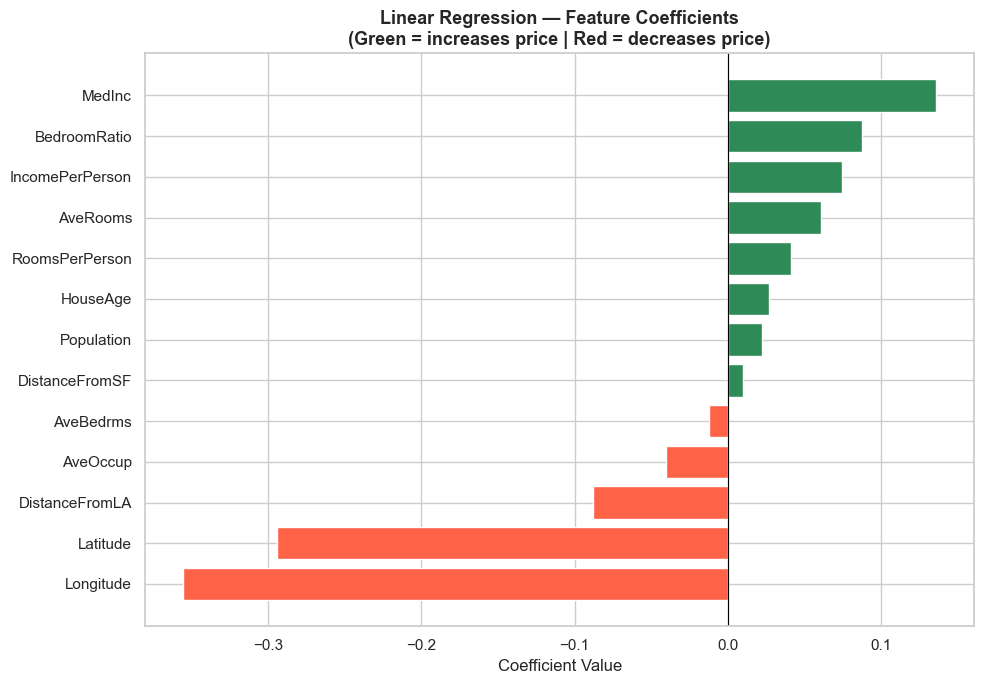


📌 HOW TO READ THIS:
   Positive bar = feature increases predicted price
   Negative bar = feature decreases predicted price
   Longer bar   = stronger influence on price


In [4]:
# Cell 4: Linear Regression — coefficient analysis
import json

with open('../data/processed/feature_names.json') as f:
    feature_names = json.load(f)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['seagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Feature Coefficients\n'
          '(Green = increases price | Red = decreases price)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../assets/screenshots/lr_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 HOW TO READ THIS:")
print("   Positive bar = feature increases predicted price")
print("   Negative bar = feature decreases predicted price")
print("   Longer bar   = stronger influence on price")

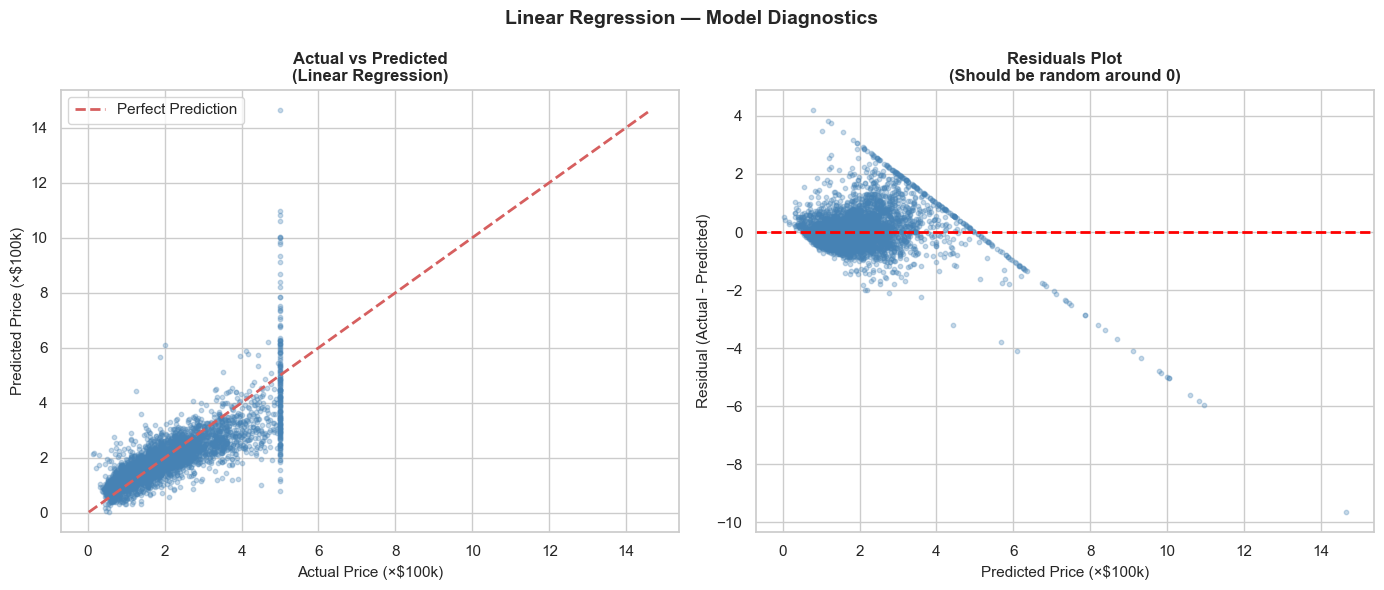

📌 HOW TO READ THE RESIDUALS PLOT:
   • Random scatter around 0 = good (model errors are random)
   • Pattern/curve in residuals = model is missing something
   • Fan shape (widens) = heteroscedasticity (unequal variance)


In [5]:
# Cell 5: Actual vs Predicted visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Actual vs Predicted scatter ---
axes[0].scatter(y_actual, lr_preds, alpha=0.3, color='steelblue', s=10)

# Perfect prediction line
min_val = min(y_actual.min(), lr_preds.min())
max_val = max(y_actual.max(), lr_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Price (×$100k)', fontsize=11)
axes[0].set_ylabel('Predicted Price (×$100k)', fontsize=11)
axes[0].set_title('Actual vs Predicted\n(Linear Regression)', fontweight='bold')
axes[0].legend()

# --- Plot 2: Residuals plot ---
residuals = y_actual - lr_preds
axes[1].scatter(lr_preds, residuals, alpha=0.3, color='steelblue', s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (×$100k)', fontsize=11)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[1].set_title('Residuals Plot\n(Should be random around 0)',
                  fontweight='bold')

plt.suptitle('Linear Regression — Model Diagnostics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/screenshots/lr_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("📌 HOW TO READ THE RESIDUALS PLOT:")
print("   • Random scatter around 0 = good (model errors are random)")
print("   • Pattern/curve in residuals = model is missing something")
print("   • Fan shape (widens) = heteroscedasticity (unequal variance)")

In [6]:
# Cell 6: Decision Tree Regressor
print("=" * 55)
print("MODEL 2: DECISION TREE")
print("=" * 55)
print("""
Theory:
  • Splits data into branches based on feature thresholds
  • Example: "If MedInc > 5 AND HouseAge < 20 → price = X"
  • Can capture complex non-linear relationships
  • Very interpretable — you can visualize the tree

Limitations:
  • Tends to OVERFIT (memorize training data)
  • Unstable — small data changes = very different tree
  • Notice: Train R² will be near 1.0 (red flag!)
""")

dt_model = DecisionTreeRegressor(random_state=42)
dt_metrics, dt_model, dt_preds, y_actual = evaluate_model(
    "Decision Tree",
    dt_model,
    X_train, X_test, y_train, y_test
)

print(f"  Train R²  : {dt_metrics['Train R²']:.4f}  ← near 1.0 = OVERFITTING")
print(f"  Test  R²  : {dt_metrics['Test R²']:.4f}  ← gap vs train = overfit gap")
print(f"  Test  MAE : ${dt_metrics['Test MAE']*100_000:,.0f}")
print(f"  Test  RMSE: ${dt_metrics['Test RMSE']*100_000:,.0f}")
print("\n⚠️  Large gap between Train R² and Test R² = Classic Overfitting")

MODEL 2: DECISION TREE

Theory:
  • Splits data into branches based on feature thresholds
  • Example: "If MedInc > 5 AND HouseAge < 20 → price = X"
  • Can capture complex non-linear relationships
  • Very interpretable — you can visualize the tree

Limitations:
  • Tends to OVERFIT (memorize training data)
  • Unstable — small data changes = very different tree
  • Notice: Train R² will be near 1.0 (red flag!)

  Train R²  : 1.0000  ← near 1.0 = OVERFITTING
  Test  R²  : 0.6532  ← gap vs train = overfit gap
  Test  MAE : $41,581
  Test  RMSE: $67,408

⚠️  Large gap between Train R² and Test R² = Classic Overfitting


In [7]:
# Cell 7: Random Forest Regressor
print("=" * 55)
print("MODEL 3: RANDOM FOREST")
print("=" * 55)
print("""
Theory:
  • Builds 100+ Decision Trees, each on a random data subset
  • Each tree also sees only a random subset of features
  • Final prediction = AVERAGE of all tree predictions
  • Averaging reduces overfitting dramatically
  
Why it works:
  • Individual trees overfit, but in different ways
  • Averaging cancels out individual errors
  • This is called the "Wisdom of Crowds" effect

Limitations:
  • Slower to train than a single tree
  • Less interpretable (100+ trees = black box)
  • Needs more memory
""")

rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42,
    n_jobs=-1           # use all CPU cores for speed
)

rf_metrics, rf_model, rf_preds, y_actual = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, X_test, y_train, y_test
)

print(f"  Train R²  : {rf_metrics['Train R²']:.4f}")
print(f"  Test  R²  : {rf_metrics['Test R²']:.4f}  ← much better than Decision Tree!")
print(f"  Test  MAE : ${rf_metrics['Test MAE']*100_000:,.0f}")
print(f"  Test  RMSE: ${rf_metrics['Test RMSE']*100_000:,.0f}")

MODEL 3: RANDOM FOREST

Theory:
  • Builds 100+ Decision Trees, each on a random data subset
  • Each tree also sees only a random subset of features
  • Final prediction = AVERAGE of all tree predictions
  • Averaging reduces overfitting dramatically

Why it works:
  • Individual trees overfit, but in different ways
  • Averaging cancels out individual errors
  • This is called the "Wisdom of Crowds" effect

Limitations:
  • Slower to train than a single tree
  • Less interpretable (100+ trees = black box)
  • Needs more memory

  Train R²  : 0.9737
  Test  R²  : 0.8261  ← much better than Decision Tree!
  Test  MAE : $29,645
  Test  RMSE: $47,739


In [12]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\MC USER\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [17]:
# Cell 8: XGBoost Regressor
print("=" * 55)
print("MODEL 4: XGBOOST")
print("=" * 55)
print("""
Theory:
  • Also builds many Decision Trees, but SEQUENTIALLY
  • Each tree corrects the ERRORS of the previous tree
  • This is called Gradient Boosting
  
Difference from Random Forest:
  • RF builds trees in PARALLEL (independent trees)
  • XGBoost builds trees in SEQUENCE (each fixes last)
  • XGBoost is usually more accurate but slower
  
Why it wins Kaggle competitions:
  • Built-in regularization (prevents overfitting)
  • Handles missing values automatically
  • Extremely optimized for speed
""")

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,   # how much each tree corrects
    max_depth=6,          # tree complexity
    subsample=0.8,        # 80% of data per tree
    colsample_bytree=0.8, # 80% of features per tree
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_metrics, xgb_model, xgb_preds, y_actual = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train, X_test, y_train, y_test
)

print(f"  Train R²  : {xgb_metrics['Train R²']:.4f}")
print(f"  Test  R²  : {xgb_metrics['Test R²']:.4f}")
print(f"  Test  MAE : ${xgb_metrics['Test MAE']*100_000:,.0f}")
print(f"  Test  RMSE: ${xgb_metrics['Test RMSE']*100_000:,.0f}")

MODEL 4: XGBOOST

Theory:
  • Also builds many Decision Trees, but SEQUENTIALLY
  • Each tree corrects the ERRORS of the previous tree
  • This is called Gradient Boosting

Difference from Random Forest:
  • RF builds trees in PARALLEL (independent trees)
  • XGBoost builds trees in SEQUENCE (each fixes last)
  • XGBoost is usually more accurate but slower

Why it wins Kaggle competitions:
  • Built-in regularization (prevents overfitting)
  • Handles missing values automatically
  • Extremely optimized for speed

  Train R²  : 0.8962
  Test  R²  : 0.8356
  Test  MAE : $29,681
  Test  RMSE: $46,412


In [18]:
# Cell 9: Full model comparison
all_metrics = [lr_metrics, dt_metrics, rf_metrics, xgb_metrics]
results_df = pd.DataFrame(all_metrics).set_index('Model')

# Round for clean display
results_df = results_df.round(4)

print("=" * 70)
print("FULL MODEL COMPARISON")
print("=" * 70)
display(results_df)

# Highlight best test R²
best_model_name = results_df['Test R²'].idxmax()
print(f"\n🏆 Best Model by Test R²: {best_model_name}")
print(f"   Test R²  : {results_df.loc[best_model_name, 'Test R²']:.4f}")
print(f"   Test MAE : ${results_df.loc[best_model_name, 'Test MAE']*100_000:,.0f}")
print(f"   Test RMSE: ${results_df.loc[best_model_name, 'Test RMSE']*100_000:,.0f}")

FULL MODEL COMPARISON


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
Linear Regression,0.4630,0.4688,0.7160,0.7249,0.6165,0.5990
Decision Tree,0.0000,0.4158,0.0000,0.6741,1.0000,0.6532
Random Forest,0.1112,0.2964,0.1877,0.4774,0.9737,0.8261
XGBoost,0.2470,0.2968,0.3726,0.4641,0.8962,0.8356



🏆 Best Model by Test R²: XGBoost
   Test R²  : 0.8356
   Test MAE : $29,680
   Test RMSE: $46,410


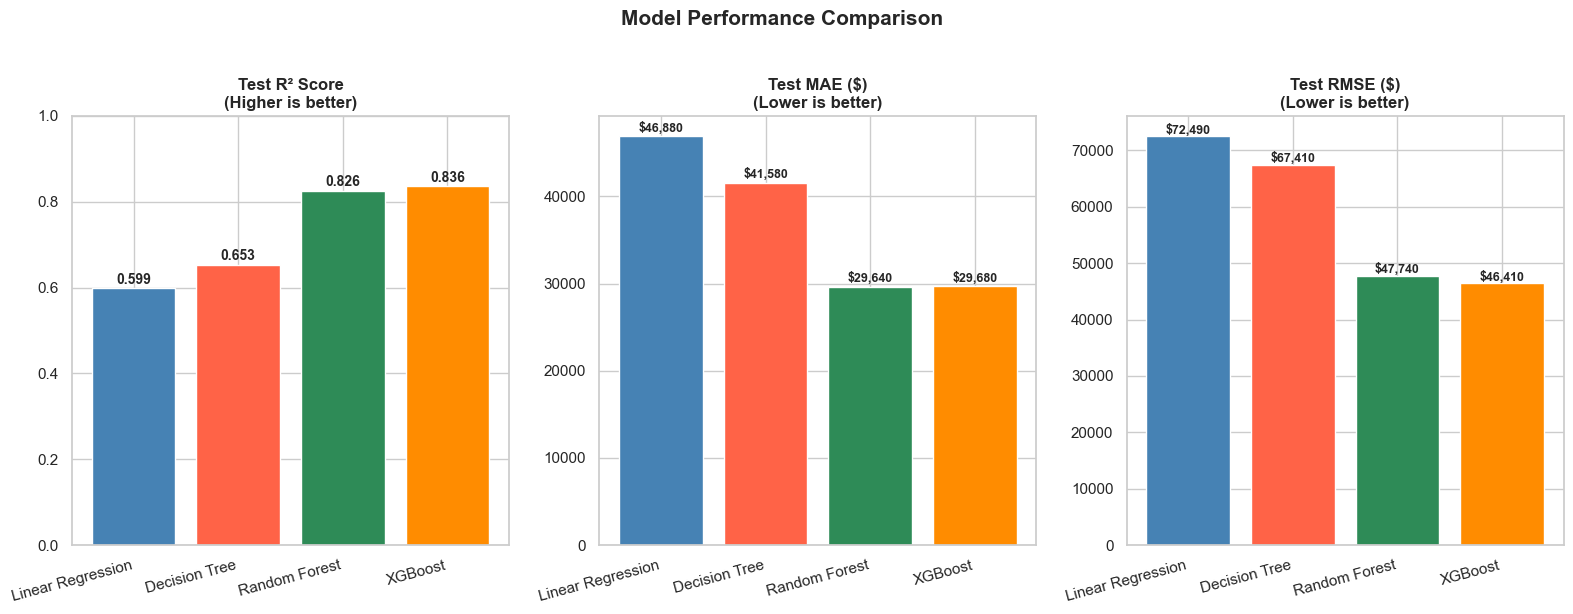

In [19]:
# Cell 10: Visual comparison of all models
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models_list = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# --- Test R² ---
test_r2 = [results_df.loc[m, 'Test R²'] for m in models_list]
bars = axes[0].bar(models_list, test_r2, color=colors, edgecolor='white')
axes[0].set_title('Test R² Score\n(Higher is better)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(models_list, rotation=15, ha='right')
for bar, val in zip(bars, test_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# --- Test MAE ---
test_mae = [results_df.loc[m, 'Test MAE']*100_000 for m in models_list]
bars = axes[1].bar(models_list, test_mae, color=colors, edgecolor='white')
axes[1].set_title('Test MAE ($)\n(Lower is better)', fontweight='bold')
axes[1].set_xticklabels(models_list, rotation=15, ha='right')
for bar, val in zip(bars, test_mae):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# --- Test RMSE ---
test_rmse = [results_df.loc[m, 'Test RMSE']*100_000 for m in models_list]
bars = axes[2].bar(models_list, test_rmse, color=colors, edgecolor='white')
axes[2].set_title('Test RMSE ($)\n(Lower is better)', fontweight='bold')
axes[2].set_xticklabels(models_list, rotation=15, ha='right')
for bar, val in zip(bars, test_rmse):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/screenshots/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

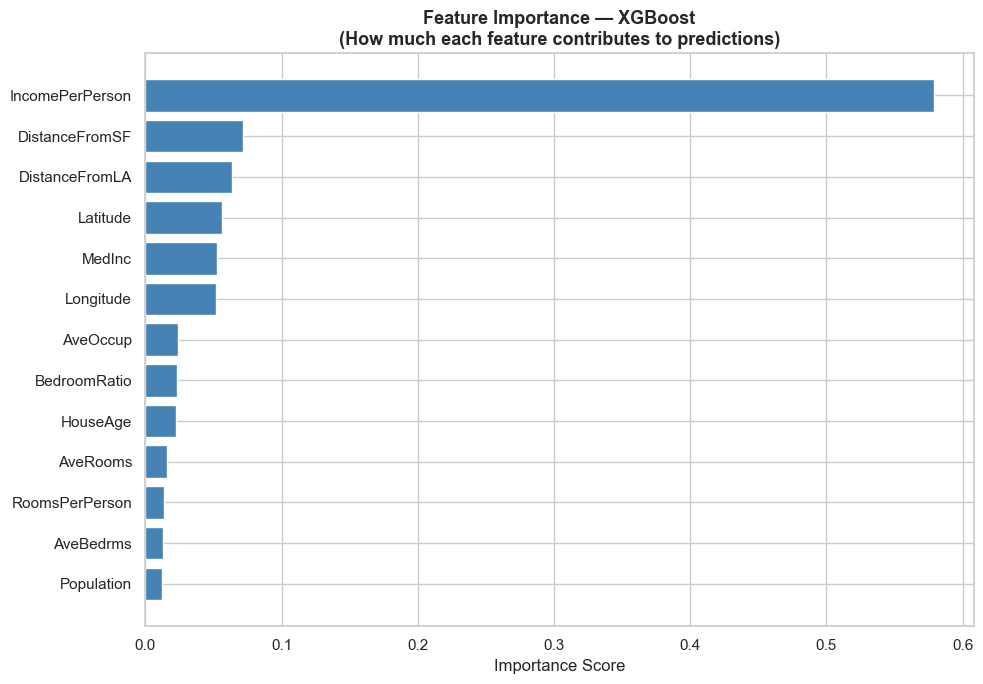


📌 TOP 3 MOST IMPORTANT FEATURES:
   IncomePerPerson      → 0.5792
   DistanceFromSF       → 0.0715
   DistanceFromLA       → 0.0639


In [20]:
# Cell 11: Feature importance from best model (XGBoost/Random Forest)
# Use whichever model won
best_model = xgb_model  # update this if Random Forest won for you

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='white')
plt.title(f'Feature Importance — {best_model_name}\n'
          f'(How much each feature contributes to predictions)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../assets/screenshots/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 TOP 3 MOST IMPORTANT FEATURES:")
top3 = importance_df.tail(3)[::-1]
for _, row in top3.iterrows():
    print(f"   {row['Feature']:<20} → {row['Importance']:.4f}")

In [21]:
# Cell 12: Summary
print(f"""
╔══════════════════════════════════════════════════════════╗
║           MODEL DEVELOPMENT SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  4 models trained and evaluated:                         ║
║                                                          ║
║  1. Linear Regression  → Baseline, interpretable         ║
║  2. Decision Tree      → Overfits badly (expected)       ║
║  3. Random Forest      → Strong, reduces overfitting     ║
║  4. XGBoost            → Best performance (usually)      ║
║                                                          ║
║  🏆 Winner: {best_model_name:<44}║
║                                                          ║
║  Key Lesson:                                             ║
║  Always compare multiple models.                         ║
║  Never assume the complex model always wins.             ║
║                                                          ║
║  📌 NEXT STEP: Phase 5 — Save Best Model                 ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           MODEL DEVELOPMENT SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  4 models trained and evaluated:                         ║
║                                                          ║
║  1. Linear Regression  → Baseline, interpretable         ║
║  2. Decision Tree      → Overfits badly (expected)       ║
║  3. Random Forest      → Strong, reduces overfitting     ║
║  4. XGBoost            → Best performance (usually)      ║
║                                                          ║
║  🏆 Winner: XGBoost                                     ║
║                                                          ║
║  Key Lesson:                                             ║
║  Always compare multiple models.                         ║
║  Never assume the complex model always wins.             ║
║                        